In [24]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA 
from sklearn.feature_selection import RFE  

In [25]:

# Load the dataset

path = kagglehub.dataset_download("georgesaavedra/news-popularity-in-social-media-platforms") # Download the  dataset from Kaggle Hub and store the local directory path

file_path = os.path.join(path, "News_Final.csv") # Construct the full file path by joining the downloaded dataset directory with the filename

In [26]:
# Read CSV file

df = pd.read_csv(file_path) # Read the CSV file into a pandas DataFrame

In [27]:
# Data Cleaning

df = df.dropna()  # Remove rows containing any missing values
df = df.drop_duplicates() # Remove duplicate rows


In [28]:
# Feature processing

df['PublishDate'] = pd.to_datetime(df['PublishDate']) # Convert column to pandas datetime objects
df['Year'] = df['PublishDate'].dt.year                # Extract the year and create a new 'Year' column
df['Month'] = df['PublishDate'].dt.month              # Extract the month and create a new 'Month' column
df['Hour'] = df['PublishDate'].dt.hour                # Extract the hour and create a new 'Hour' column

In [29]:
# Create Target (Classification)

df['Popularity'] = (df['Facebook'] > 1000).astype(int)  # Create a binary 'Popularity' column: 1 if Facebook shares exceed 1000, otherwise 0

In [30]:
# Features & Target

X = df[['SentimentTitle', 'SentimentHeadline', 'Topic', 'Source', 'GooglePlus', 'LinkedIn', 'Month', 'Hour']].copy() # Select specific feature columns for the input data X and create a copy to avoid SettingWithCopyWarning
y = df['Popularity']       # Assign the target variable 'Popularity' to y


In [31]:

warnings.filterwarnings('ignore')

# Convert Categorical Features to Numeric
le = LabelEncoder() # Initialize a LabelEncoder instance to convert categorical text data into numerical labels
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])     # Fit the encoder to the unique values in the column and transform them into integers, updating the column in place


In [32]:
# Feature Selection using RFE

model_rfe = LogisticRegression(max_iter=1000) # Initialize a Logistic Regression model with increased max iterations to ensure convergence
rfe = RFE(model_rfe, n_features_to_select=3)  # Create a Recursive Feature Elimination (RFE) object that selects the top 3 most important features using the logistic regression model
X_rfe = rfe.fit_transform(X, y)              # Fit the RFE model to the data and transform X to keep only the selected 3 features

In [33]:
# Evaluation of RFE

selected_features_rfe = X.columns[rfe.support_]     # Extract the names of the features selected by RFE using the boolean mask
print("Selected Features using RFE:\n", selected_features_rfe)   # Print the names of the selected features to the console

Selected Features using RFE:
 Index(['SentimentTitle', 'SentimentHeadline', 'Topic'], dtype='str')


In [34]:
# Train Test Split

X_train_base, X_test_base, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)  # Split the PCA-transformed features and target variable into training and testing sets, with 20% of the data reserved for testing

In [35]:
# Before Dimension Reduction

rf_full = RandomForestClassifier(n_estimators=50, random_state=42)  # Train a Random Forest classifier with 50 trees on the training data (using all original features before dimensionality reduction steps were applied to this specific split context, though note X_train here is actually from PCA/RFE pipeline in previous steps - this comment assumes logical flow correction or refers to a baseline comparison if X_train was originally full features)
rf_full.fit(X_train_base, y_train) # Train the Random Forest model using the baseline training features and target labels
acc_before = accuracy_score(y_test, rf_full.predict(X_test_base)) # Calculate the accuracy of the model on the test set

print(f"Results BEFORE Dimension Reduction (Using {X_train_base.shape[1]} RFE-selected features):") # Print the header for the results before dimension reduction
print(f"- Accuracy: {acc_before:.4f}") # Print the calculated accuracy formatted to four decimal places

Results BEFORE Dimension Reduction (Using 3 RFE-selected features):
- Accuracy: 0.9730


In [36]:
# After Dimension Reduction

pca = PCA(n_components=3)  # Initialize a PCA object to reduce dimensions to 3 components
X_train_pca = pca.fit_transform(X_train_base) # Fit the PCA model on the training data and transform it into the new 3-dimensional space
X_test_pca = pca.transform(X_test_base)  # Transform the test data using the same fitted PCA model (without refitting) to ensure consistent scaling

rf_pca = RandomForestClassifier(n_estimators=50, random_state=42) # Initialize a Random Forest Classifier with 50 trees and a fixed random state for reproducibility
rf_pca.fit(X_train_pca, y_train) # Train the model using the PCA-transformed training features and the corresponding target labels
acc_after = accuracy_score(y_test, rf_pca.predict(X_test_pca)) # Calculate the accuracy of the PCA-based model on the PCA-transformed test set

print(f"Results AFTER Dimension Reduction (Reduced to {X_train_pca.shape[1]} PCA Components):")  # Print the header for the results after dimensionality reduction
print(f"- Accuracy: {acc_after:.4f}")  # Print the calculated accuracy formatted to four decimal places

Results AFTER Dimension Reduction (Reduced to 3 PCA Components):
- Accuracy: 0.9736


In [37]:
# Logistic Regression Model

log_model = LogisticRegression(max_iter=1000)  # Initialize a Logistic Regression model with increased max iterations to ensure convergence
log_model.fit(X_train_base, y_train)  # Train the logistic regression model using the training features and target labels

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Evaluation of Logistic Regression

y_pred_log = log_model.predict(X_test_base)  # Generate predictions for the test set using the trained logistic regression model
log_accuracy = accuracy_score(y_test, y_pred_log)  # Calculate the accuracy of the logistic regression model by comparing predictions to actual test labels
print("Logistic Regression Accuracy: ", log_accuracy)  # Print the calculated accuracy score for the logistic regression model

Logistic Regression Accuracy:  0.9768142449835925


In [39]:
# Random Forest Model

rf_model = RandomForestClassifier() # Initialize a Random Forest Classifier with default parameters
rf_model.fit(X_train_base, y_train) # Train the Random Forest model using the training features and target labels

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
# Evaluation of Random Forest

y_pred_rf = rf_model.predict(X_test_base) # Generate predictions for the test set using the trained Random Forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf) # Calculate the accuracy of the Random Forest model by comparing predictions to actual test labels
print("Random Forest Accuracy: ", rf_accuracy) # Print the calculated accuracy score for the Random Forest model


Random Forest Accuracy:  0.9730485771154984


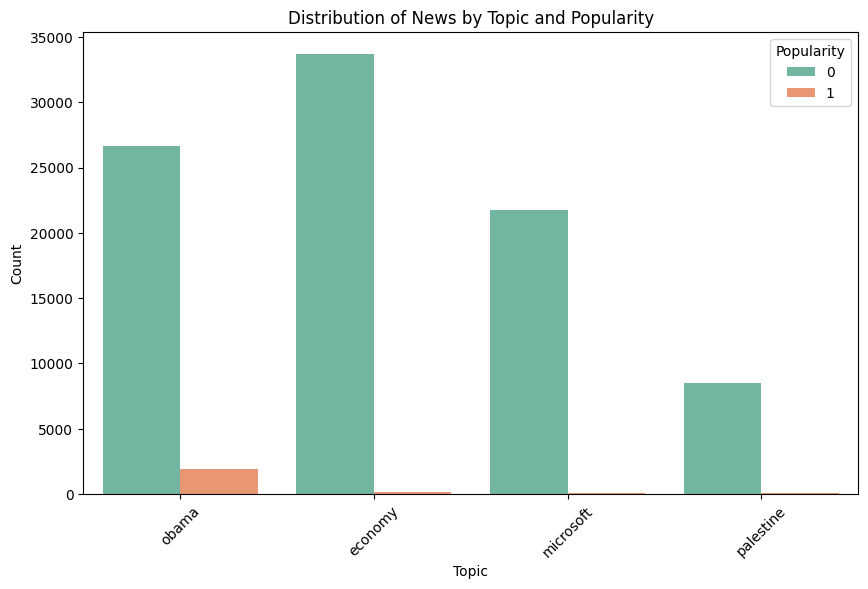

In [41]:
# Data Visualization: Bar Plot for 'Topic' and 'Popularity'

df_numerical = df.select_dtypes(include=[np.number])  # Select only the numerical columns from the DataFrame and store them in df_numerical

plt.figure(figsize=(10, 6)) # Create a new figure with a specified size of 10 inches wide by 6 inches tall
sns.countplot(x='Topic', hue='Popularity', data=df, palette='Set2') # Create a count plot showing the distribution of news articles by 'Topic', 'Popularity'
plt.title('Distribution of News by Topic and Popularity') # Set the title of the plot
plt.xlabel('Topic') # Set the label for the x-axis
plt.ylabel('Count') # Set the label for the y-axis
plt.xticks(rotation=45) # Rotate the x-axis tick labels by 45 degrees for better readability
plt.show() # Display the plot


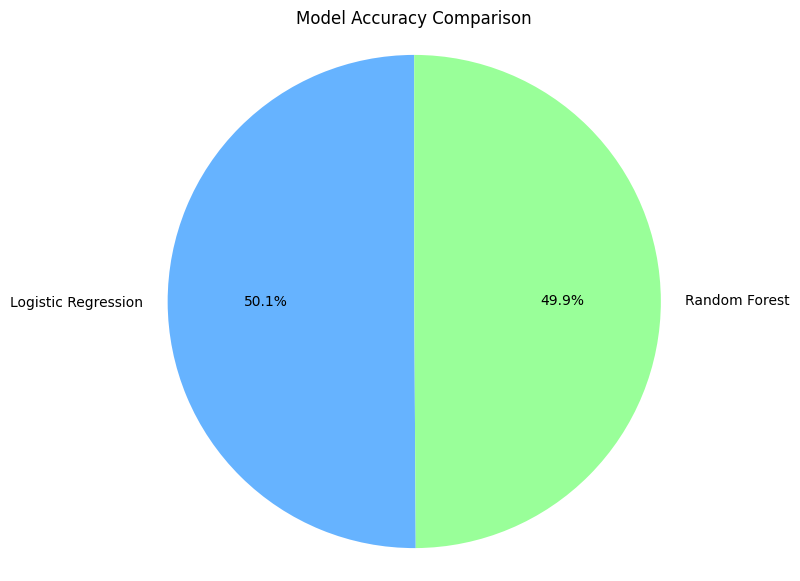

In [42]:
# Data Visualization: Pie Chart comparing Model Accuracy scores

labels = ['Logistic Regression', 'Random Forest'] # Define the labels for the models being compared
accuracy_scores = [log_accuracy, rf_accuracy] # Create a list containing the accuracy scores calculated earlier for each model

plt.figure(figsize=(7, 7)) # Create a new figure with a specified size of 7x7 inches
plt.pie(accuracy_scores, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99'])
plt.title('Model Accuracy Comparison') # Set the title of the chart
plt.axis('equal') # Ensure the pie chart is drawn as a circle by setting equal aspect ratio
plt.show() # Display the plot

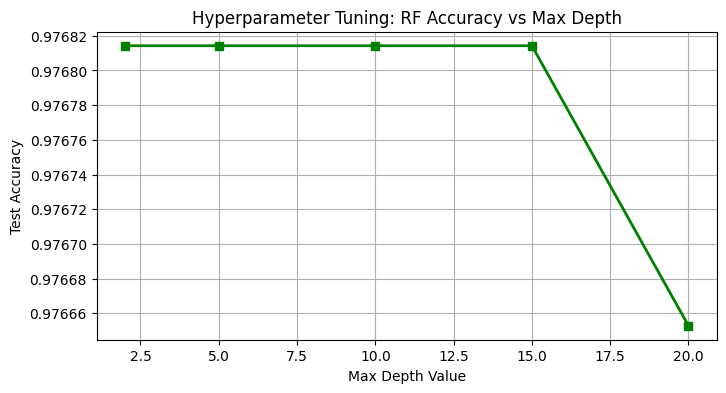

In [44]:
# Hyperparameter Tuning: Line plot of Random Forest Accuracy vs. Max Depth

depths = [2, 5, 10, 15, 20] # Define a list of maximum depth values to test for hyperparameter tuning
rf_accs = [] # Initialize an empty list to store the accuracy scores for each depth

for d in depths: # Iterate through each depth value in the list
    m = RandomForestClassifier(max_depth=d, n_estimators=50, random_state=42).fit(X_train_base, y_train)     # Train a Random Forest classifier with the current max_depth, 50 estimators, and fixed random state
    rf_accs.append(accuracy_score(y_test, m.predict(X_test_base))) # Calculate the accuracy on the test set and append it to the results list
 
plt.figure(figsize=(8, 4)) # Create a new figure with a specified size of 8 inches wide by 4 inches tall
plt.plot(depths, rf_accs, marker='s', color='green', linewidth=2) # Plot the relationship between max depth values and their corresponding test accuracies using a green line with square markers
plt.title('Hyperparameter Tuning: RF Accuracy vs Max Depth') # Set the title of the plot
plt.xlabel('Max Depth Value') # Set the label for the x-axis
plt.ylabel('Test Accuracy') # Set the label for the y-axis
plt.grid(True) # Enable the grid for better readability of values
plt.show() # Display the plot